In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import sklearn as sk

[Data Source](https://omniweb.gsfc.nasa.gov/ftpbrowser/soho_ephin_flux_hr.html)

In [2]:
proton_flux_df = pd.read_csv('data/enviromental/ephin-soho/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+") 
proton_flux_df

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Lewis\AppData\Local\Temp\ipykernel_28852\2513693952.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  proton_flux_df = pd.read_csv('data/enviromental/ephin-soho/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+")


,Year,DOY,Hour,P4,P8,P25,P41
0,1995,342,0,0.000042,0.000020,0.000065,0.000049
1,1995,342,1,0.000028,0.000036,0.000069,0.000061
2,1995,342,2,0.000014,0.000027,0.000068,0.000073
3,1995,342,3,0.000041,0.000034,0.000069,0.000074
4,1995,342,4,0.000028,0.000027,0.000033,0.000062
...,...,...,...,...,...,...,...
53899,2002,30,19,0.114190,0.009482,0.000173,0.000050
53900,2002,30,20,0.109340,0.008745,0.000191,0.000054
53901,2002,30,21,0.108360,0.008860,0.000185,0.000046
53902,2002,30,22,0.108220,0.009084,0.000184,0.000053


# Power Law Spectrum
**[Torres 2025](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024SW003921)**: The 
10 MeV proton intensity is calculated from the differential fluxes in four energy (P4, P8, P25, and P41) channels through an integration over the energy. The P8 proton channel covers an energy range of 7.8–25 MeV, P25 covers 25–40.9 MeV, P41 covers 40.9–53 MeV, while the P4 channel covers 4.3–7.8 MeV. We assume that particles above the P41 channel coverage make little contribution to the integral flux of MeV protons. The integral flux is calculated by summing energy-integrated fluxes in the last three (P8, P25, and P41) channels minus the amount between 7.8 and 10 MeV, which is determined by the integration of a power-law spectrum interpolated using the differential fluxes in the first two channels (P4 and P8) and their mean energies. We use the first two channels to do the interpolation because their fluxes have relatively low error bars due to high count rates in low-energy channels.

Too find channel between 7.8- 10 MeV we fall the Power Law Scale and make use of its invariance:

$\Phi_n = \alpha \nu_n^\beta$ (1)

Using the channels P4 and P8:

$\Phi_4 = \alpha \nu_4^\beta$ (2) 

$\Phi_8 = \alpha \nu_8^\beta$ (3)

Converting frequency to energy: $\nu_n = \frac{\bar{E}_n}{h}$ (4), $h = 4.136 \times 10^{-21} \text{Mev/s}$

Rewriting (2): $\alpha = \frac{\Phi_4}{\nu_4^\beta}$

And then plugging into (3): $\Phi_8 = \Phi_4 \left(\frac{\nu_8}{\nu_4} \right)^\beta$ (5)

Solving for $\beta$: $\beta = \frac{\log [\Phi_8 / \Phi_4]}{\log [\nu_8 / \nu_4]}$

Solving for $\alpha$: $\alpha = \frac{\Phi_4}{\nu_4^\beta}$ With newly discovered $\beta$

Now we can solve the flux over any range we want using our new parameters $\alpha, \beta$: $\Phi_x = \alpha \nu_x^\beta$




In [3]:
def Power_Law_Spectrum_Flux(a_lower_bound_energy, a_upper_bound_energy, a_p4_flux, a_p4_avg_E,  a_p8_flux, a_p8_avg_E):
    h = 4.136e-21 # MeV / s
    a_p4_freq = a_p4_avg_E / h
    a_p8_freq = a_p8_avg_E / h
    new_freq  = (a_lower_bound_energy + a_upper_bound_energy)/(2*h)
    beta_denom = np.log(a_p8_freq / a_p4_freq) 



    beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
    alpha = a_p4_flux / a_p4_freq**beta
    new_flux = alpha * new_freq ** beta

    return new_flux

In [4]:
def Integrating_Flux(a_df):
    new_channel_lower_bound = 7.8
    new_channel_upper_bound = 10
    p4_avg_energy = (4.3+7.8)/2 # MeV
    p8_avg_energy = (25+7.8) / 2 # MeV

    a_df["Px"] = a_df.apply(
        lambda row: Power_Law_Spectrum_Flux(
            new_channel_lower_bound, 
            new_channel_upper_bound, 
            row["P4"], 
            p4_avg_energy, 
            row["P8"], 
            p8_avg_energy
        ), 
        axis=1
    )
    a_df["P_tot"] = a_df["P4"] + a_df["P25"] + a_df["P41"] - a_df["Px"]
    a_df["Timestamp"] = pd.to_datetime(a_df["Year"], format="%Y") + pd.to_timedelta(a_df["DOY"] - 1, unit = "D") + pd.to_timedelta(a_df["Hour"], unit = "h")
    a_df = a_df[a_df["P_tot"] != 1.999980e+06] # Cleaned from error numbers?
    return a_df
proton_flux_df = Integrating_Flux(proton_flux_df)

C:\Users\Lewis\AppData\Local\Temp\ipykernel_28852\1720685650.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
C:\Users\Lewis\AppData\Local\Temp\ipykernel_28852\1720685650.py:12: RuntimeWarning: invalid value encountered in scalar multiply
  new_flux = alpha * new_freq ** beta
C:\Users\Lewis\AppData\Local\Temp\ipykernel_28852\1720685650.py:10: RuntimeWarning: invalid value encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
C:\Users\Lewis\AppData\Local\Temp\ipykernel_28852\1720685650.py:10: RuntimeWarning: divide by zero encountered in log
  beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
C:\Users\Lewis\AppData\Local\Temp\ipykernel_28852\1720685650.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = a_p4_flux / a_p4_freq**beta


# Finding Onset, Peaks, and Ends
No specific technique was explained rather the "program" will sort it. heres my attempt and i will compare with theirs

In [ ]:
def Timestamp_Proton_Flux(a_indices, a_df):
    a_df = a_df.reset_index(drop=True)
    proton_fluxes = a_df["P_tot"]
    years         = a_df["Year"]
    DOYs          = a_df["DOY"]
    hours         = a_df["Hour"]
    fluxes    = proton_fluxes.loc[a_indices]
    years     = years.loc[a_indices]
    DOY       = DOYs.loc[a_indices]
    hours     = hours.loc[a_indices]
    timestamp = pd.to_datetime(years, format="%Y") + pd.to_timedelta(DOY - 1, unit="D") + pd.to_timedelta(hours, unit="h")
    return fluxes, timestamp


def Find_Proton_Flux_Phases(a_df, a_range, a_file_name):
    a_df = a_df.dropna()
    print(a_df.isnull().values.any())
    proton_fluxes = a_df["P_tot"]
    years         = a_df["Year"]
    DOYs          = a_df["DOY"]
    hours         = a_df["Hour"]

    peak_indices, properties = find_peaks(proton_fluxes.to_list(), height=10, distance=a_range)

    peak_years     = years.iloc[peak_indices]
    peak_DOYs      = DOYs.iloc[peak_indices]
    peak_hours     = hours.iloc[peak_indices]
    peak_dates     = pd.to_datetime(peak_years, format="%Y") + pd.to_timedelta(peak_DOYs - 1, unit="D")
    peak_timestamp = (peak_dates + pd.to_timedelta(peak_hours, unit="h")).reset_index(drop=True)

    onset_indices     = []
    threshold_indices = []
    end_indices       = []

    for i in range(len(peak_indices)):
        peak_index = int(peak_indices[i])
        #print("Sectioning Phase #", i)

        # --- Background: find quiet 24-hour window ---
        b = 0
        background_noise = proton_fluxes.iloc[peak_index - 24: peak_index]
        while (background_noise > 2).any():
           # print("Testing background", b)
            background_noise = proton_fluxes.iloc[peak_index - 24 - b: peak_index - b]
            #print(background_noise)
            b += 1

        mean_bg   = background_noise.mean()
        std_bg    = background_noise.std()
        onset_check = mean_bg + 3 * std_bg
        #print("background Value", onset_check)


        # --- Onset: walk backward from peak until flux <= onset_check ---
        current_onset_index = peak_index
        while current_onset_index > 0 and proton_fluxes.iloc[current_onset_index] > onset_check:
            current_onset_index -= 1
        onset_indices.append(current_onset_index)
        #print(proton_fluxes[onset_indices])

        # --- Threshold: walk forward from onset until flux >= 10 ---
        current_threshold_index = current_onset_index
        while proton_fluxes.iloc[current_threshold_index] < 10:
            current_threshold_index += 1
            if current_threshold_index >= peak_index:
                current_threshold_index = peak_index
                break
        threshold_indices.append(current_threshold_index)

        # --- End: walk forward from peak until flux < 2 ---
        current_end_index = peak_index
        while current_end_index < len(proton_fluxes) - 1 and proton_fluxes.iloc[current_end_index] > 2:
            current_end_index += 1
        end_indices.append(current_end_index)

    onset_fluxes,     onset_timestamp     = Timestamp_Proton_Flux(onset_indices, a_df)
    threshold_fluxes, threshold_timestamp = Timestamp_Proton_Flux(threshold_indices, a_df)
    end_fluxes,       end_timestamp       = Timestamp_Proton_Flux(end_indices, a_df)
    peak_fluxes = pd.Series(properties['peak_heights'])

    phases_df = pd.DataFrame({
        'Onset Timestamp':     onset_timestamp.reset_index(drop=True),
        'Onset Flux':          onset_fluxes.reset_index(drop=True),
        'Threshold Timestamp': threshold_timestamp.reset_index(drop=True),
        'Threshold Flux':      threshold_fluxes.reset_index(drop=True),
        'Peak Timestamp':      peak_timestamp,
        'Peak Flux':           peak_fluxes,
        'End Timestamp':       end_timestamp.reset_index(drop=True),
        'End Flux':            end_fluxes.reset_index(drop=True)
    })

    phases_df["Storm Duration"] = phases_df["End Timestamp"] - phases_df["Onset Timestamp"]
    phases_df.to_csv("data/phases/" + a_file_name + "-" + str(a_range) + ".csv")
    return phases_df


Find_Proton_Flux_Phases(proton_flux_df, 55, "phases_11061997_11032002")

False


,Onset Timestamp,Onset Flux,Threshold Timestamp,Threshold Flux,Peak Timestamp,Peak Flux,End Timestamp,End Flux,Storm Duration
0,1997-11-06 13:00:00,0.994949,1997-11-06 22:00:00,13.861737,1997-11-07 06:00:00,48.236460,1997-11-09 13:00:00,1.529511,3 days 00:00:00
1,1998-04-20 17:00:00,0.607296,1998-04-21 00:00:00,11.187188,1998-04-21 10:00:00,31.837132,1998-04-23 22:00:00,1.874275,3 days 05:00:00
2,1998-05-06 07:00:00,0.055902,1998-05-06 10:00:00,17.482761,1998-05-06 10:00:00,17.482761,1998-05-07 08:00:00,1.295521,1 days 01:00:00
3,1998-11-06 05:00:00,1.056892,1998-11-06 09:00:00,10.984583,1998-11-06 15:00:00,17.353562,1998-11-08 09:00:00,1.720839,2 days 04:00:00
4,1998-11-14 09:00:00,0.879883,1998-11-14 13:00:00,13.861132,1998-11-14 13:00:00,13.861132,1998-11-21 16:00:00,0.002832,7 days 07:00:00
5,1999-04-24 16:00:00,0.115716,1999-04-25 01:00:00,11.289432,1999-04-25 01:00:00,11.289432,1999-04-25 13:00:00,1.950103,0 days 21:00:00
6,1999-05-05 13:00:00,1.021368,1999-05-06 01:00:00,12.007922,1999-05-06 01:00:00,12.007922,1999-05-07 15:00:00,1.925622,2 days 02:00:00
7,1999-06-02 02:00:00,0.454050,1999-06-02 06:00:00,10.309662,1999-06-02 06:00:00,10.309662,1999-06-02 09:00:00,1.713128,0 days 07:00:00
8,1999-06-04 08:00:00,0.292685,1999-06-04 11:00:00,13.955859,1999-06-04 14:00:00,27.388799,1999-06-06 07:00:00,1.997960,1 days 23:00:00
9,2000-04-04 17:00:00,0.012237,2000-04-05 01:00:00,11.364914,2000-04-05 19:00:00,51.056354,2000-04-06 19:00:00,1.718519,2 days 02:00:00


False


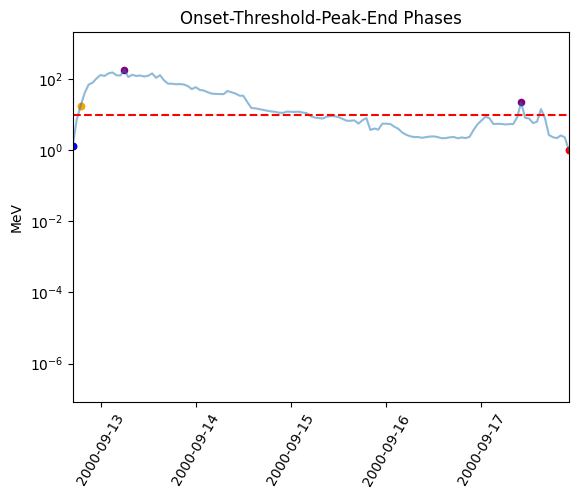

In [52]:
phase_data_df = Find_Proton_Flux_Phases(proton_flux_df, 100, "phases_11061997_11032002")

plt.title("Onset-Threshold-Peak-End Phases")
plt.ylabel("MeV")
plt.style.use("default")
plt.plot(proton_flux_df["Timestamp"], proton_flux_df["P_tot"], alpha = .5)


plt.scatter(phase_data_df["Onset Timestamp"], phase_data_df["Onset Flux"], c = "blue", s = 20 )


plt.scatter(phase_data_df["Threshold Timestamp"], phase_data_df["Threshold Flux"], c ="orange", s = 20 )

plt.scatter(phase_data_df["End Timestamp"], phase_data_df["End Flux"], c ="red", s = 20 )

plt.scatter(phase_data_df["Peak Timestamp"], phase_data_df["Peak Flux"], c = "purple", s = 20)

plt.xticks(rotation = 60)
plt.yscale("log")
plt.axhline(y=10, color='r', linestyle='--')
plt.xlim(
    pd.Timestamp("2000-09-12 17:00:00"),
    pd.Timestamp("2000-09-17 22:00:00")
)
plt.show()

# Ex 1.  GOES-16 SEU timestamped data with SOHO Proton Flux

## Linear Regression of SEU instances and Proton Fluxes



In [26]:
goes_16_seu_df = pd.read_excel("data/seu_timestamp/g16_g17_exs_spw.xlsx", sheet_name= "g16_exs_spw" )

goes_16_proton_flux = pd.read_csv("data/enviromental/ephin-soho/proton_flux_2016Dec-2022Mar_EPHINSOHO.lst", header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+")
goes_16_proton_flux = Integrating_Flux(goes_16_proton_flux)

goes_16_proton_flux_phases = Find_Proton_Flux_Phases(goes_16_proton_flux, 200, "goes16_proton_flux_phases")
goes_16_proton_flux

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Lewis\AppData\Local\Temp\ipykernel_36760\419877746.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  goes_16_proton_flux = pd.read_csv("data/enviromental/ephin-soho/proton_flux_2016Dec-2022Mar_EPHINSOHO.lst", header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+")
C:\Users\Lewis\AppData\Local\Temp\ipykernel_36760\1720685650.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
C:\Users\Lewis\AppData\Local\Temp\ipykernel_36760\1720685650.py:12: RuntimeWarning: invalid value encoun

,Year,DOY,Hour,P4,P8,P25,P41,Px,P_tot,Timestamp
0,2016,345,0,0.004439,0.000084,0.000015,0.000015,0.000956,0.003513,2016-12-10 00:00:00
1,2016,345,1,0.004437,0.000054,0.000015,0.000015,0.000808,0.003659,2016-12-10 01:00:00
2,2016,345,2,0.004539,0.000069,0.000022,0.000035,0.000897,0.003699,2016-12-10 02:00:00
3,2016,345,3,0.004199,0.000073,0.000015,0.000020,0.000873,0.003361,2016-12-10 03:00:00
4,2016,345,4,0.004568,0.000059,0.000022,0.000066,0.000851,0.003805,2016-12-10 04:00:00
...,...,...,...,...,...,...,...,...,...,...
46099,2022,73,19,0.014632,0.000330,0.000091,0.000087,0.003373,0.011437,2022-03-14 19:00:00
46100,2022,73,20,0.012191,0.000301,0.000127,0.000172,0.002911,0.009579,2022-03-14 20:00:00
46101,2022,73,21,0.017689,0.000656,0.000764,0.000635,0.004940,0.014147,2022-03-14 21:00:00
46102,2022,73,22,0.012741,0.000410,0.000404,0.000644,0.003370,0.010418,2022-03-14 22:00:00


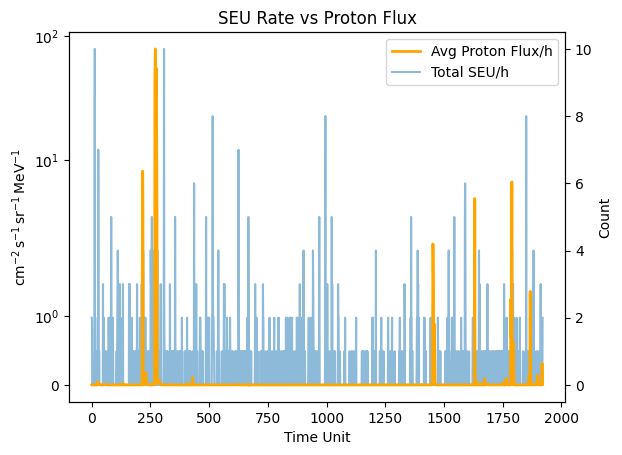

In [27]:
goes_16_seu_df["Count"] = np.ones(goes_16_seu_df.shape[0])

goes_16_seu_rate_df = goes_16_seu_df.groupby(pd.Grouper(key= "Datetime", freq = "D")).sum() 
goes_16_proton_flux_mean = goes_16_proton_flux.groupby(pd.Grouper(key = "Timestamp", freq = "D")).mean()



proton_flux_seu_rate_df = pd.concat([goes_16_seu_rate_df["Count"], goes_16_proton_flux_mean["P_tot"]], axis = 1, keys = ['SEU/h', "Flux/h"]).dropna()


fig, ax1 = plt.subplots()

# -----------------------------------
# LEFT AXIS (FRONT)
# -----------------------------------

ax1.set_zorder(2)
ax1.patch.set_visible(False)

ax1.set_title("SEU Rate vs Proton Flux")

ax1.set_xlabel("Time Unit")

ax1.set_ylabel(
    r"$\mathrm{cm}^{-2}\,\mathrm{s}^{-1}\,\mathrm{sr}^{-1}\,\mathrm{MeV}^{-1}$"
)

ax1.set_yscale('symlog')

line1 = ax1.plot(
    np.arange(0, len(goes_16_proton_flux_mean), 1),
    goes_16_proton_flux_mean["P_tot"].to_numpy(),
    linewidth=2,
    label="Avg Proton Flux/h",
    zorder=3,
    color = "orange"
)

# -----------------------------------
# RIGHT AXIS (BACK)
# -----------------------------------

ax2 = ax1.twinx()

ax2.set_zorder(1)

ax2.set_ylabel("Count")

line2 = ax2.plot(
    np.arange(0, goes_16_seu_rate_df.shape[0], 1),
    goes_16_seu_rate_df["Count"],
    alpha=0.5,
    label="Total SEU/h",
    zorder=1
)

# -----------------------------------
# LEGEND
# -----------------------------------

lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels)

plt.show()

In [28]:
X = proton_flux_seu_rate_df["Flux/h"].to_numpy().astype(np.float32).reshape(-1,1)
X = X[~np.isnan(X)].reshape(-1,1)
y = proton_flux_seu_rate_df["SEU/h"].to_numpy().astype(np.float32)
y = y[~np.isnan(y)]
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X,y,test_size = .20)

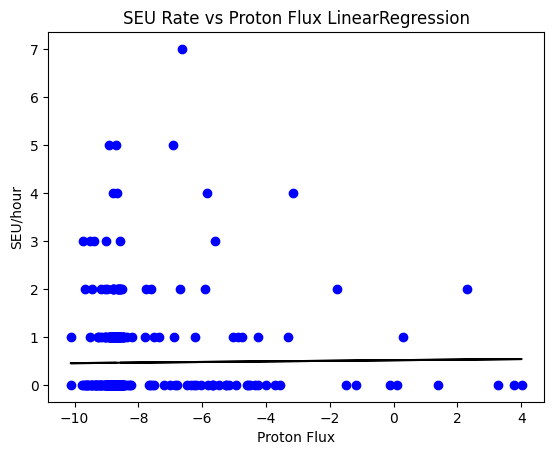

Mean Absolute Error: 0.6589756608009338
Mean Sqaure Error: 0.8601280450820923
Root Mean Square Error: 0.9274308842615132
Model Score: -0.0037461519241333008


In [29]:
def Lin_Fit_SEU_Rate_Proton_Flux(a_X_train, a_X_test, a_y_train, a_y_test, a_model):
    a_X_test = np.log(a_X_test)
    a_X_train= np.log(a_X_train)

    a_model.fit(a_X_train, a_y_train)
    y_pred = a_model.predict(a_X_test)
    fig, ax = plt.subplots()
    ax.scatter(a_X_test, a_y_test, color = "b")
    ax.set_xlabel("Proton Flux")
    ax.set_title("SEU Rate vs Proton Flux " +type(a_model).__name__)
    ax.set_ylabel("SEU/hour")
    ax.plot(a_X_test, y_pred, color = 'k')
    plt.show()
    
    print("Mean Absolute Error:", sk.metrics.mean_absolute_error(y_true= y_test, y_pred = y_pred))
    print("Mean Sqaure Error:", sk.metrics.mean_squared_error(y_true = y_test, y_pred = y_pred))
    print("Root Mean Square Error:", np.sqrt(sk.metrics.mean_squared_error(y_true = y_test, y_pred = y_pred)))
    print("Model Score:", a_model.score(X_test,y_test))

Lin_Fit_SEU_Rate_Proton_Flux(X_train, X_test, y_train, y_test, sk.linear_model.LinearRegression())

In [30]:
# from sklearn.compose import TransformedTargetRegressor as ttr

# regr = ttr(regressor = sk.linear_model.LinearRegression(), func = np.log, inverse_func= np.exp)
# regr.fit(X_train, y_train)

The average linear regression model score tends to 0 indicating something wrong. non linear relationship between SEU occurences and proton fluxes? not enough occurences of SEUs in dataset? too noisy? Trying to compare SEU on GOES-16 with SOHO proton flux?


# Gaussian Process of SEU instances and Proton Fluxes
I tried using the sklearn gaussian process regressor but this takes way to long with 45,000 data points for both proton flux and hourly seu. I have a 5070 on my desktop and im going to use it. here comes gpytorch: https://richardcsuwandi.medium.com/gaussian-process-regression-using-gpytorch-2c174286f9cc

In [31]:
# kernel = 1.0 * sk.gaussian_process.kernels.RBF(length_scale = 1.0)
# gp = sk.gaussian_process.GaussianProcessRegressor(kernel = kernel)
# def Gauss_Fit_SEU_Rate_Proton_Flux(a_X_train, a_X_test, a_y_train, a_y_test, a_model):

#     # Fit model
#     a_model.fit(a_X_train, a_y_train)
    
#     # Predict
#     y_pred = a_model.predict(a_X_test)

#     # Plot
#     plt.scatter(a_X_test, a_y_test, color="b")
#     plt.xlabel("Proton Flux")
#     plt.ylabel("SEU/hour")
#     plt.title("SEU Rate vs Proton Flux " + type(a_model).__name__)

#     # Sort for smooth curve
#     sorted_idx = np.argsort(a_X_test.flatten())
#     plt.plot(a_X_test.flatten()[sorted_idx], y_pred[sorted_idx], color='k')

#     plt.show()

#     # Metrics
#     print("Mean Absolute Error:", sk.metrics.mean_absolute_error(a_y_test, y_pred))
#     print("Mean Squared Error:", sk.metrics.mean_squared_error(a_y_test, y_pred))
#     print("Root Mean Square Error:", np.sqrt(sk.metrics.mean_squared_error(a_y_test, y_pred)))
#     print("Model Score:", a_model.score(a_X_test, a_y_test))

# Gauss_Fit_SEU_Rate_Proton_Flux(X_train,X_test,y_train,y_test, gp)

In [32]:
# import gpytorch as gp
# import torch

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using Device: {device}")

# X_train = torch.from_numpy(X_train).float()
# y_train = torch.from_numpy(y_train).float()

# # -------------------------
# # Define GP Model
# # -------------------------
# class SpectralMixtureGP(gp.models.ExactGP):
#     def __init__(self, x_train, y_train, likelihood):
#         super(SpectralMixtureGP, self).__init__(x_train, y_train, likelihood)
#         self.mean = gp.means.ConstantMean() # Construct the mean function
#         self.cov = gp.kernels.SpectralMixtureKernel(num_mixtures=4) # Construct the kernel function
#         self.cov.initialize_from_data(x_train, y_train) # Initialize the hyperparameters from data
        
#     def forward(self, x):
#         # Evaluate the mean and kernel function at x
#         mean_x = self.mean(x)
#         cov_x = self.cov(x)
#         # Return the multivariate normal distribution using the evaluated mean and kernel function
#         return gp.distributions.MultivariateNormal(mean_x, cov_x) 
        
# # Initialize the likelihood and model
# likelihood = gp.likelihoods.GaussianLikelihood()
# model = SpectralMixtureGP(X_train, y_train, likelihood)

# # -------------------------
# # Initialize likelihood + model ON GPU
# # -------------------------
# likelihood = gp.likelihoods.GaussianLikelihood()
# model = SpectralMixtureGP(X_train, y_train, likelihood)

# # -------------------------
# # Training mode
# # -------------------------
# model.train()
# likelihood.train()

# # -------------------------
# # Optimizer + Loss
# # -------------------------
# optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
# mll = gp.mlls.ExactMarginalLogLikelihood(likelihood, model)

# # -------------------------
# # Training loop
# # -------------------------
# n_iter = 50

# for i in range(n_iter):
#     optimizer.zero_grad()

#     output = model(X_train)  # stays on GPU
#     loss = -mll(output, y_train)

#     loss.backward()

#     print(f"Iter {i+1}/{n_iter} - Loss: {loss.item():.3f}")

#     optimizer.step()

In [33]:
# model.eval()
# likelihood.eval()
# # print(X_test.float())
# X_testa = torch.from_numpy(np.float32(X_test))
# y_testa = torch.from_numpy(y_test)

# with torch.no_grad(), gp.settings.fast_pred_var():
#     # Obtain the predictive mean and covariance matrix
#     f_preds = model(X_testa)
#     f_mean = f_preds.mean
#     f_cov = f_preds.covariance_matrix
    
#     # Make predictions by feeding model through likelihood
#     observed_pred = likelihood(model(X_testa))
    
#     # Initialize plot
#     f, ax = plt.subplots(1, 1, figsize=(8, 6))
#     # Get upper and lower confidence bounds
#     lower, upper = observed_pred.confidence_region()
#     # Plot training data as black stars
#     ax.plot(X_train.numpy(), y_train.numpy(), 'k*')
#     # Plot predictive means as blue line
#     ax.plot(X_testa.numpy(), observed_pred.mean.numpy(), 'b')
#     # Shade between the lower and upper confidence bounds
#     ax.fill_between(X_testa.numpy().flatten(), lower.numpy(), upper.numpy(), alpha=0.5)

#     ax.legend(['Observed Data', 'Mean', 'Confidence']) 


# EX 2. GOES 16 SEU Events with GOES Proton Flux
              GOES-13 Proton Fluence     GOES-13 Electron Fluence     Neutron
            --- Protons/cm2-day-sr ---  -- Electrons/cm2-day-sr --    Monitor

https://www.ncei.noaa.gov/data/goes-space-environment-monitor/access/avg/


In [34]:
import os
PATH = "data/enviromental/goes/"
goes_proton_flux_files = os.listdir(PATH)

goes_proton_flux_df = pd.DataFrame()

for f in range(len(goes_proton_flux_files)):
    goes_file = pd.read_csv(PATH + goes_proton_flux_files[f],
                            skiprows = 716, sep = ",")
    goes_file["time_tag"] = pd.to_datetime(goes_file["time_tag"])
    #goes_file = goes_file.groupby(pd.Grouper(key = 'time_tag', freq = "h")).mean()
    goes_proton_flux_df = pd.concat([goes_proton_flux_df, goes_file]).reset_index(drop = True)
    goes_proton_flux_df = goes_proton_flux_df.sort_values(by = 'time_tag')

x = np.arange(0,goes_proton_flux_df.shape[0],1)


plt.bar(x,goes_proton_flux_df["ZPGT10E"])
plt.bar(x,goes_proton_flux_df["ZPGT10W"], alpha = .5)
plt.yscale("log")
plt.plot()

[]

Error in callback <function flush_figures at 0x0000021FE98A4D50> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 